<a href="https://colab.research.google.com/github/nishachaudhary6396/MachineLearning/blob/Project/01_Approval_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('hdfc_loan.csv')

In [25]:
data=df[['Applicant_Income','Annual_Household_Income','CIBIL_Score','Debt_to_Income_Ratio','Loan_Status']].copy()
data.reset_index()


,index,Applicant_Income,Annual_Household_Income,CIBIL_Score,Debt_to_Income_Ratio,Loan_Status
0,0,56976,683712,699,0.098,Approved
1,1,1856,22272,707,4.939,Rejected
2,2,64553,774636,641,0.000,Approved
3,3,88450,1061400,677,0.301,Approved
4,4,9539,114468,594,0.000,Approved
...,...,...,...,...,...,...
995,995,44713,536556,707,0.116,Approved
996,996,70886,850632,561,0.284,Rejected
997,997,24392,428748,725,0.966,Approved
998,998,64803,1907268,679,0.214,Approved


In [26]:
data['Loan_Status'] = np.where(data['Loan_Status'] =="Approved",1,0)
data

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Debt_to_Income_Ratio,Loan_Status
0,56976,683712,699,0.098,1
1,1856,22272,707,4.939,0
2,64553,774636,641,0.000,1
3,88450,1061400,677,0.301,1
4,9539,114468,594,0.000,1
...,...,...,...,...,...
995,44713,536556,707,0.116,1
996,70886,850632,561,0.284,0
997,24392,428748,725,0.966,1
998,64803,1907268,679,0.214,1


In [27]:
approval_rate_overall=data['Loan_Status'].mean()*100
approval_rate_overall

np.float64(65.3)

In [28]:
Debt=data['Annual_Household_Income']*data['Debt_to_Income_Ratio']
data['Financial_Indicator']=np.where(data['Loan_Status']==0,'Not Applicable',np.where(Debt>data['Annual_Household_Income'],'Healthy','Manageable'))
data

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Debt_to_Income_Ratio,Loan_Status,Financial_Indicator
0,56976,683712,699,0.098,1,Manageable
1,1856,22272,707,4.939,0,Not Applicable
2,64553,774636,641,0.000,1,Manageable
3,88450,1061400,677,0.301,1,Manageable
4,9539,114468,594,0.000,1,Manageable
...,...,...,...,...,...,...
995,44713,536556,707,0.116,1,Manageable
996,70886,850632,561,0.284,0,Not Applicable
997,24392,428748,725,0.966,1,Manageable
998,64803,1907268,679,0.214,1,Manageable


In [52]:
data['approval_rate_particular']=np.where(Debt>data['Annual_Household_Income'], 25,np.where(Debt< data['Annual_Household_Income'],70,50))
data

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Debt_to_Income_Ratio,Loan_Status,Financial_Indicator,approval_rate_particular,Income_Band,Credit_Score_Band
0,56976,683712,699,0.098,1,Manageable,70,High Income,Fair
1,1856,22272,707,4.939,0,Not Applicable,25,Low Income,Good
2,64553,774636,641,0.000,1,Manageable,70,Premium Income,Fair
3,88450,1061400,677,0.301,1,Manageable,70,Premium Income,Fair
4,9539,114468,594,0.000,1,Manageable,70,Low Income,Poor
...,...,...,...,...,...,...,...,...,...
995,44713,536556,707,0.116,1,Manageable,70,High Income,Good
996,70886,850632,561,0.284,0,Not Applicable,70,Premium Income,Poor
997,24392,428748,725,0.966,1,Manageable,70,Middle Income,Good
998,64803,1907268,679,0.214,1,Manageable,70,Premium Income,Fair


In [30]:
X=Debt
A=data['approval_rate_particular']
dA_dX=np.gradient(A,X)
dA_dX

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1246: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1246: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1247: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1247: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/py

array([-1.04656926e-03, -1.45565494e-03, -6.23903325e-04,             nan,
        0.00000000e+00,  1.35525272e-20, -5.89274681e-05, -1.94238542e-04,
                   nan,  8.04291443e-04,  0.00000000e+00, -3.52365706e-19,
       -1.49077799e-19,  0.00000000e+00,  1.08420217e-19,  0.00000000e+00,
        1.28749008e-19, -2.71050543e-20,             nan,  4.33680869e-19,
        4.05826755e-04,  1.68109557e-04, -3.51097666e-03, -1.02376189e-04,
       -2.52713505e-04, -4.55183333e-04, -6.17270891e-05,  6.48959396e-04,
       -6.30481840e-04,  0.00000000e+00, -4.33680869e-19,             nan,
                   nan,             nan,  5.83083839e-04, -1.69666678e-05,
        0.00000000e+00,  7.38079589e-07,  9.62256533e-05, -5.83976294e-04,
       -1.07854573e-03, -1.77596984e-04, -4.33680869e-19,  2.71050543e-20,
        2.16840434e-19,  2.16840434e-19,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -2.16840434e-19, -6.03489571e-04, -1.06028391e-03,
        2.93013193e-04,  

Task 1
Perform exploratory analysis.
Study:
Income distribution
Credit score distribution
Approval distribution


In [31]:
income = data['Applicant_Income']
np.mean(income)
np.std(income)

28119.140644972584

Text(0.5, 1.0, 'Applicant Income Distribution')

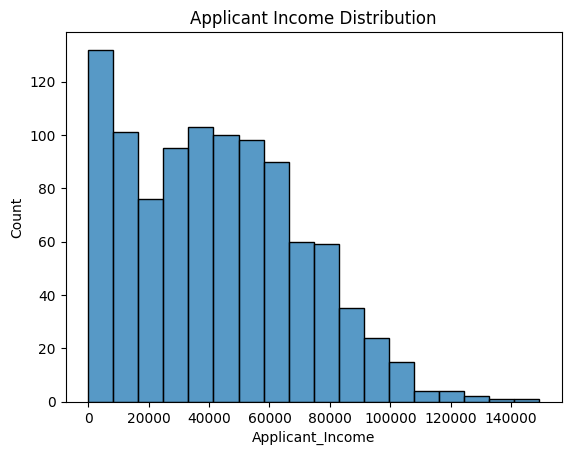

In [32]:
sns.histplot(income)
plt.title('Applicant Income Distribution')

Text(0.5, 1.0, 'CIBIL Score Distribution')

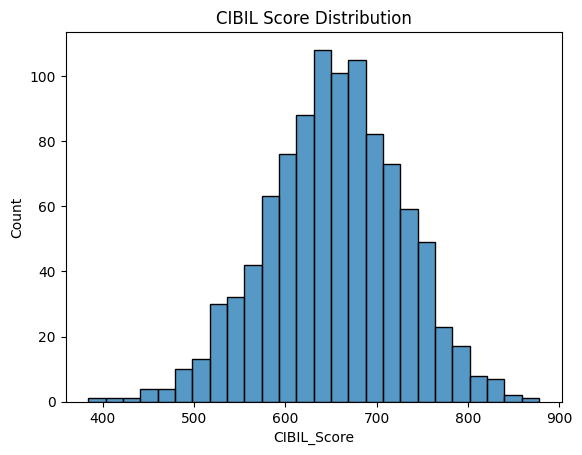

In [33]:
score = data['CIBIL_Score']
np.mean(score)
np.std(score)
sns.histplot(score)
plt.title('CIBIL Score Distribution')

Approval Rate Visualization

Text(0.5, 1.0, 'Approval Distribution')

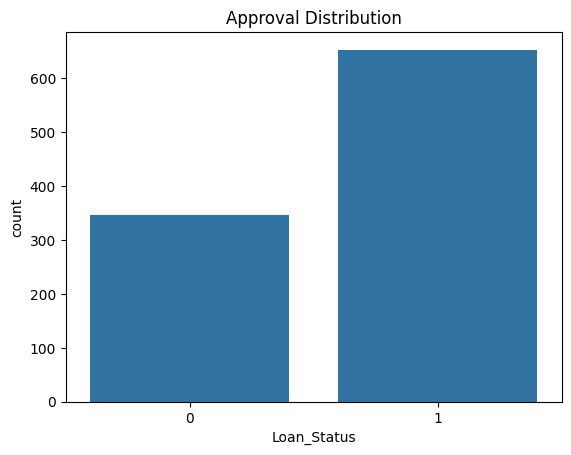

In [34]:
sns.countplot(x='Loan_Status',data=data)
plt.title('Approval Distribution')

Task 2
Group applicants into bands.
Example:
Income Bands

Low Income
Middle Income
High Income
Premium Income


In [35]:
income = data['Applicant_Income']
p25 = np.percentile(income,25)
p50 = np.percentile(income,50)
p75 = np.percentile(income,75)
p25,p50,p75

(np.float64(18260.0), np.float64(40675.5), np.float64(61037.25))

In [36]:
data['Income_Band'] = np.where(data['Applicant_Income'] <=p25,'Low Income',
                               np.where(data['Applicant_Income'] <= p50,'Middle Income',
                                        np.where(data['Applicant_Income'] <=p75,'High Income', 'Premium Income')))

Text(0.5, 1.0, 'Income Band Distribution')

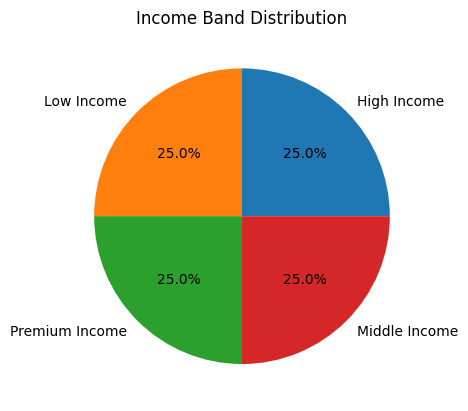

In [37]:
band_counts = data['Income_Band'].value_counts()
plt.pie(
    band_counts,
    labels=band_counts.index,
    autopct='%1.1f%%'
)
plt.title('Income Band Distribution')

Task 3
Calculate approval rate for each band.


In [38]:
approval_rate_income_band = data.groupby('Income_Band')['Loan_Status'].mean()*100
approval_rate_income_band

,Loan_Status
Income_Band,
High Income,80.0
Low Income,30.4
Middle Income,63.6
Premium Income,87.2


Task 4
Use numerical differentiation to calculate the rate of change in approval rates.
Example:
np.gradient(approval_rates)


In [39]:
rate_of_change = np.gradient(approval_rate_income_band)
rate_of_change

array([-49.6,  -8.2,  28.4,  23.6])

Task 5
Identify critical thresholds where approval rates increase or decrease sharply.


In [40]:
min_index = np.argmin(rate_of_change)
max_index = np.argmax(rate_of_change)
min_index,max_index

(np.int64(0), np.int64(2))

#visualizations

Create:
Visual 1
Income Band vs Approval Rate


Text(0.5, 1.0, 'Income Band vs Approval Rate')

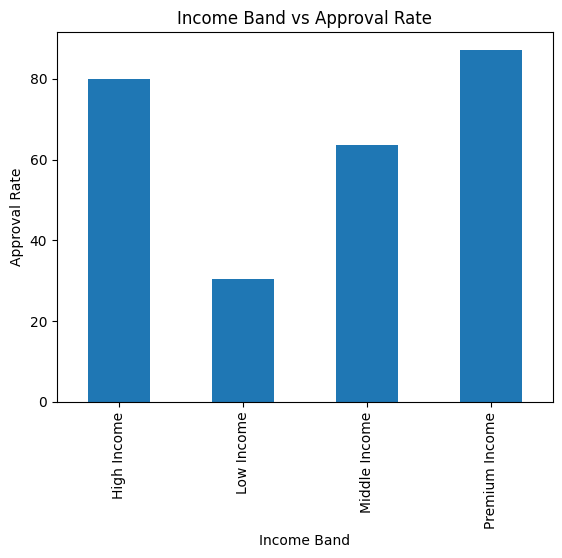

In [41]:
approval_rate_income_band.plot(kind='bar')
plt.xlabel('Income Band')
plt.ylabel('Approval Rate')
plt.title('Income Band vs Approval Rate')

Visual 2
Credit Score Band vs Approval Rate


In [42]:
data['Credit_Score_Band'] = pd.cut(
    data['CIBIL_Score'],
    bins=[300,600,700,800,900],
    labels=['Poor','Fair','Good','Excellent']
)

In [43]:
approval_rate_credit = (
    data.groupby('Credit_Score_Band')['Loan_Status'].mean()*100
)

/tmp/ipykernel_1615/286374663.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Credit_Score_Band')['Loan_Status'].mean()*100


Text(0.5, 1.0, 'Credit Score Band vs Approval Rate')

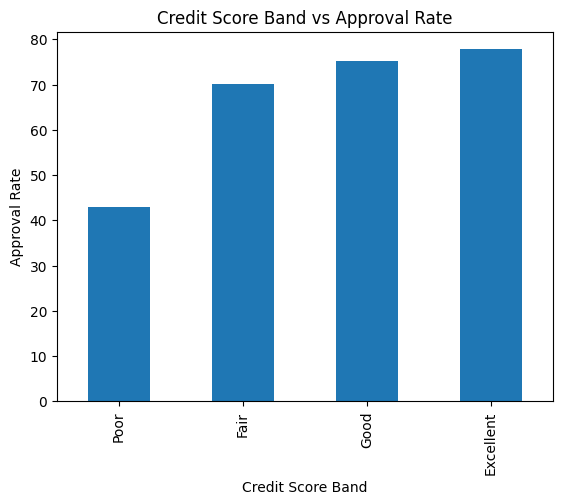

In [44]:
approval_rate_credit.plot(kind='bar')
plt.xlabel('Credit Score Band')
plt.ylabel('Approval Rate')
plt.title('Credit Score Band vs Approval Rate')

Visual 3
Rate of Change Curve


Text(0.5, 1.0, 'Rate of Change Curve')

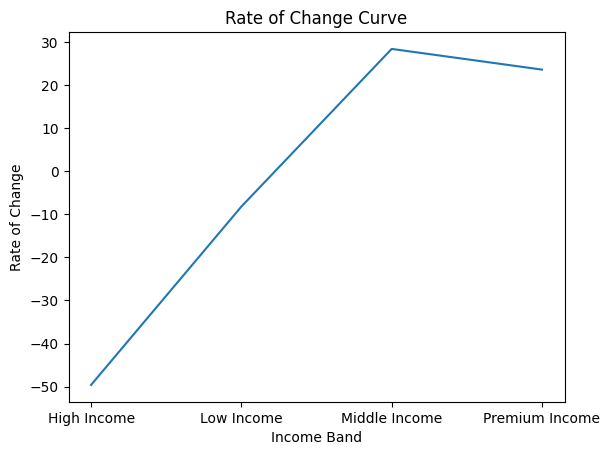

In [45]:
plt.plot(approval_rate_income_band.index,rate_of_change)
plt.xlabel('Income Band')
plt.ylabel('Rate of Change')
plt.title('Rate of Change Curve')

Visual 4
Feature Sensitivity Comparison


In [49]:
income_gradient = np.gradient(approval_rate_income_band)
credit_gradient = np.gradient(approval_rate_credit)
income_sensitivity = np.mean(np.abs(income_gradient))
credit_sensitivity = np.mean(np.abs(credit_gradient))

In [50]:
sensitivity = pd.Series({
    'Income': income_sensitivity,
    'Credit Score': credit_sensitivity
})

Text(0, 0.5, 'Sensitivity')

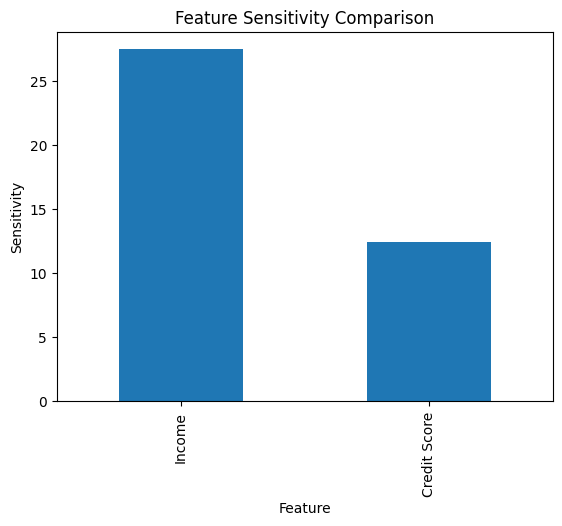

In [51]:
sensitivity.plot(kind='bar')

plt.title("Feature Sensitivity Comparison")
plt.xlabel("Feature")
plt.ylabel("Sensitivity")